<a href="https://colab.research.google.com/github/juanes0789/ciencia-de-datos-proyecto-de-aula-20261/blob/main/sesiones_practicas/sp_4_Juan_Mosquera_Maria_Mosquera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img src="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/imgs/banner_fcd.jpg?raw=1" alt="bannersp" width="1100"  height="150">

## <span style="color:#2F749F;"><strong>📦 Sesión práctica 4: Detección de datos atípicos</strong></span>
---
<p align="right">
  <a href="https://github.com/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_4_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>


## <span style="color:black;"><strong>Datos del estudiante</strong></span>

- Juan Esteban Mosquera Perea
- Maria Paula Mosquera Alvarez



# <span style="color:#2F749F;"><strong>Ejercicio 1: Intervalo IQR</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

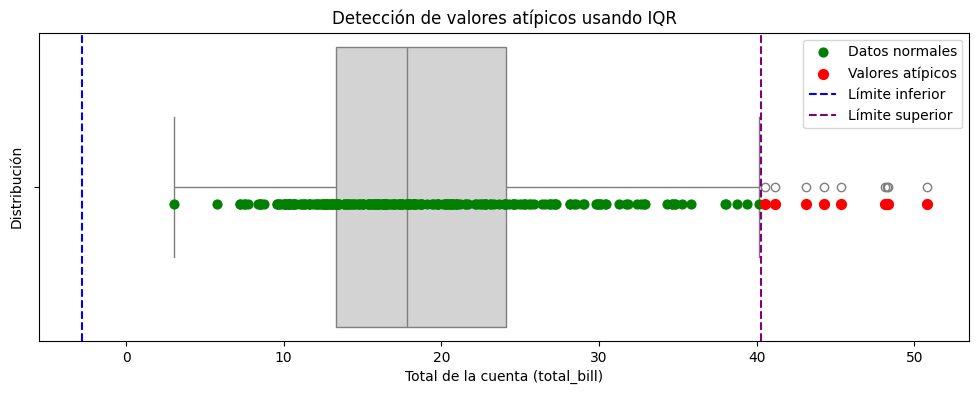

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
tips = sns.load_dataset("tips")
total_bill = tips["total_bill"].values

# Calcular cuartiles e IQR
Q1, Q3 = np.percentile(total_bill, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

# Separar datos
data_a = total_bill[(total_bill < lim_inf) | (total_bill > lim_sup)]  # atípicos
data_b = total_bill[(total_bill >= lim_inf) & (total_bill <= lim_sup)]  # normales

# Gráfica
plt.figure(figsize=(12,4))

# Boxplot
sns.boxplot(x=total_bill, color="lightgray")

# Datos normales
plt.scatter(data_b, [0.05]*len(data_b), color="green", s=40, label="Datos normales", zorder=5)

# Datos atípicos
plt.scatter(data_a, [0.05]*len(data_a), color="red", s=50, label="Valores atípicos", zorder=6)

# Líneas de límites
plt.axvline(lim_inf, color='blue', linestyle='--', label='Límite inferior')
plt.axvline(lim_sup, color='purple', linestyle='--', label='Límite superior')

# Etiquetas
plt.xlabel("Total de la cuenta (total_bill)")
plt.ylabel("Distribución")
plt.title("Detección de valores atípicos usando IQR")

# Leyenda
plt.legend()

plt.show()

Los valores atípicos corresponden a cuentas inusualmente altas, lo que puede correspnder a cuentas de grupos grandes, o eventos especiales. La ausencia de atípicos inferiores sugiere que existe un minimo natural en el gasto, probablemente asociado a precios mínimos del menú o consumo básico por cliente.

# <span style="color:#2F749F;"><strong>Ejercicio 2: Graficos de dispersión</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

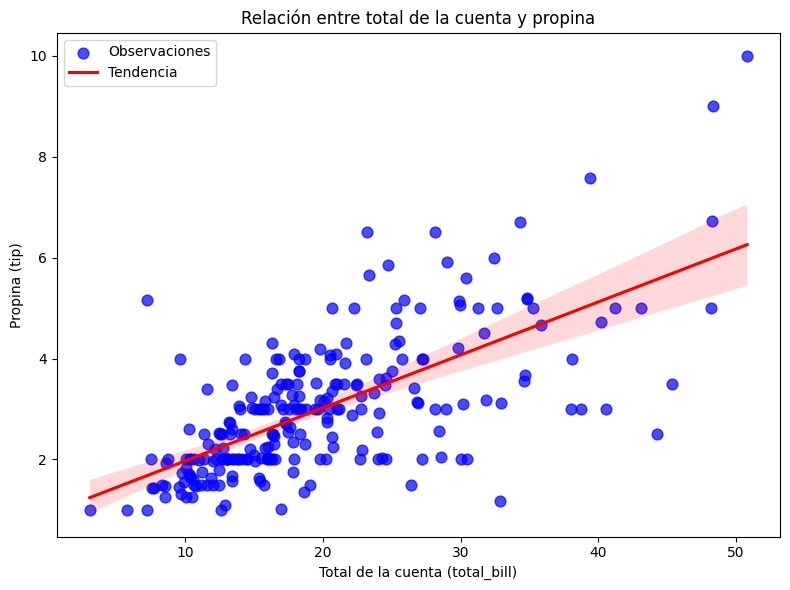

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Cargar datos
tips = sns.load_dataset("tips")

x = tips["total_bill"].values
y = tips["tip"].values

# Gráfica
plt.figure(figsize=(8,6))

# Scatter principal
plt.scatter(x, y, color="blue", s=60, alpha=0.7, label="Observaciones")

# Línea de tendencia
sns.regplot(x=x, y=y, scatter=False, color="red", label="Tendencia")

# Etiquetas
plt.xlabel("Total de la cuenta (total_bill)")
plt.ylabel("Propina (tip)")
plt.title("Relación entre total de la cuenta y propina")

# Leyenda
plt.legend()

plt.tight_layout()
plt.show()

El analisis de la grafica de relacion entre el total de la cuenta y propina muestra una correlacion positiva entre el total de la cuenta y la propina, donde a mayor es el total, mayor es la propina. Hay puntos alejados de la nube central que pueden deberse tanto a la variabilidad normal de los datos como a la variación de clientes con diferentes habitos de consumo y generosidad.

# <span style="color:#2F749F;"><strong>Ejercicio 3: Histogramas y funciones de densidad</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

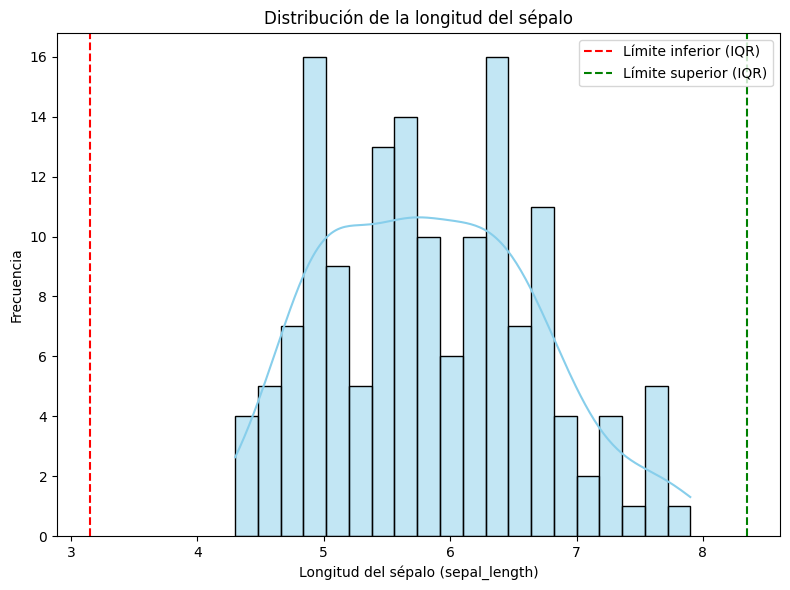

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Cargar datos
iris = sns.load_dataset("iris")
x = iris["sepal_length"].values

# Cálculo de límites IQR
Q1, Q3 = np.percentile(x, [25, 75])
IQR = Q3 - Q1
lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

# Gráfica
plt.figure(figsize=(8,6))

# Histograma + densidad
sns.histplot(x=x, bins=20, kde=True, color="skyblue")

# Líneas de referencia
plt.axvline(lim_inf, color='red', linestyle='--', label='Límite inferior (IQR)')
plt.axvline(lim_sup, color='green', linestyle='--', label='Límite superior (IQR)')

# Etiquetas
plt.xlabel("Longitud del sépalo (sepal_length)")
plt.ylabel("Frecuencia")
plt.title("Distribución de la longitud del sépalo")

# Leyenda
plt.legend()

plt.tight_layout()
plt.show()

El histograma de la longitud del sépalo muestra una distribución, con una ligera cola a la derecha, con la mayoría de los datos concentrados entre 5 y 7 cm. Las líneas de referencia del IQR indican que los límites inferior y superior se encuentran fuera del rango de los datos observados. Según el método IQR, no se identifican valores atípicos en la longitud del sépalo para este conjunto de datos. La ausencia de atípicos indica una homogeneidad relativa en esta característica dentro del dataset Iris.

# <span style="color:#2F749F;"><strong>Ejercicio 4: Z-Score</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

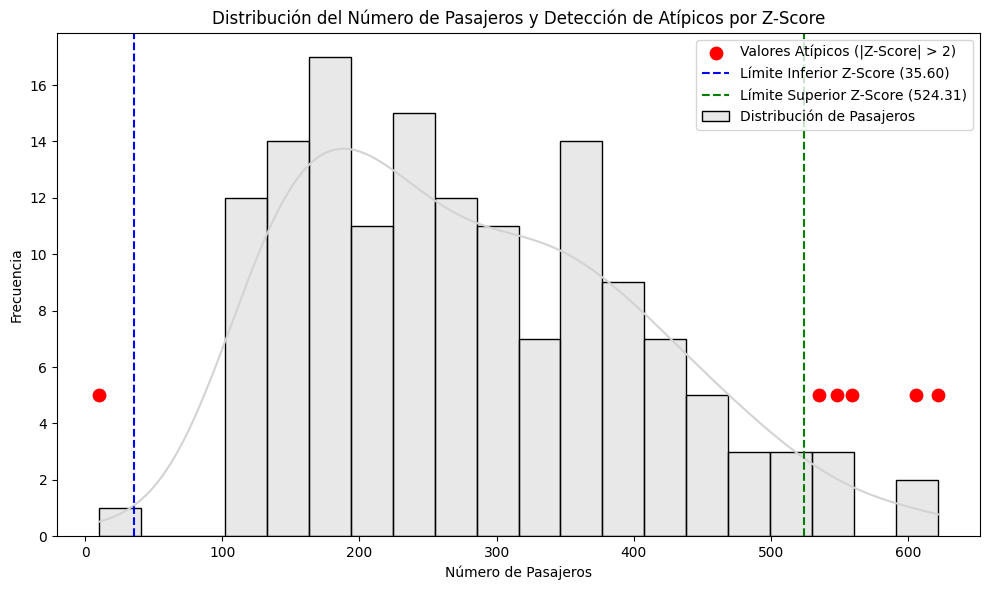

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import zscore

flights = sns.load_dataset("flights")
x = flights["passengers"].values

x = np.append(x, [10, 500]) # Añadimos intencionadamente valores atípicos

z_scores = zscore(x)
data_b = np.abs(z_scores) > 2

plt.figure(figsize=(10,6))

# Histograma
sns.histplot(x=x, bins=20, kde=True, color="lightgray", label="Distribución de Pasajeros")

# Obtener media y desviación estándar del conjunto de datos
mean_x = np.mean(x)
std_x = np.std(x)

# Calcular los límites del Z-Score
lower_bound_z = mean_x - 2 * std_x
upper_bound_z = mean_x + 2 * std_x


plt.scatter(x[data_b], np.zeros_like(x[data_b]) + 5,
            color="red", s=80, marker="o", zorder=5, label="Valores Atípicos (|Z-Score| > 2)")

# Líneas de referencia para los límites del Z-Score
plt.axvline(lower_bound_z, color='blue', linestyle='--', label=f'Límite Inferior Z-Score ({lower_bound_z:.2f})')
plt.axvline(upper_bound_z, color='green', linestyle='--', label=f'Límite Superior Z-Score ({upper_bound_z:.2f})')

# Etiquetas y título
plt.xlabel("Número de Pasajeros")
plt.ylabel("Frecuencia")
plt.title("Distribución del Número de Pasajeros y Detección de Atípicos por Z-Score")

# Leyenda
plt.legend()

plt.tight_layout()
plt.show()

El histograma muestra la distribución del número de pasajeros a lo largo del tiempo, la cual presenta una forma asimétrica, con una cola extendida hacia la derecha, indicando que la mayoría de los vuelos tienen un número de pasajeros menor, pero existen algunos vuelos con una cantidad significativamente mayor. Observamos puntos fuera de ambos límites del z-score, tanto en la parte inferior como en la superior, reoresentando outliers. Estos pueden corresponder a situaciones inusuales, como vuelos casi vacíos o vuelos con una demanda muy alta o eventos especiales.

# <span style="color:#2F749F;"><strong>Ejercicio 5: K-means</strong></span>

A partir de siguiente código:

1. Ajusta el código para mejorar la interpretación de la gráfica. Mínimo debes:
   - Indicar los nombres de los ejes
   - Incluir legenda para comprender lo que esté incluído en la gráfica
2. Generar máximo 5 líneas de análisis sobre lo que observas en términos de defición de atípicos sobre tú gráfica final

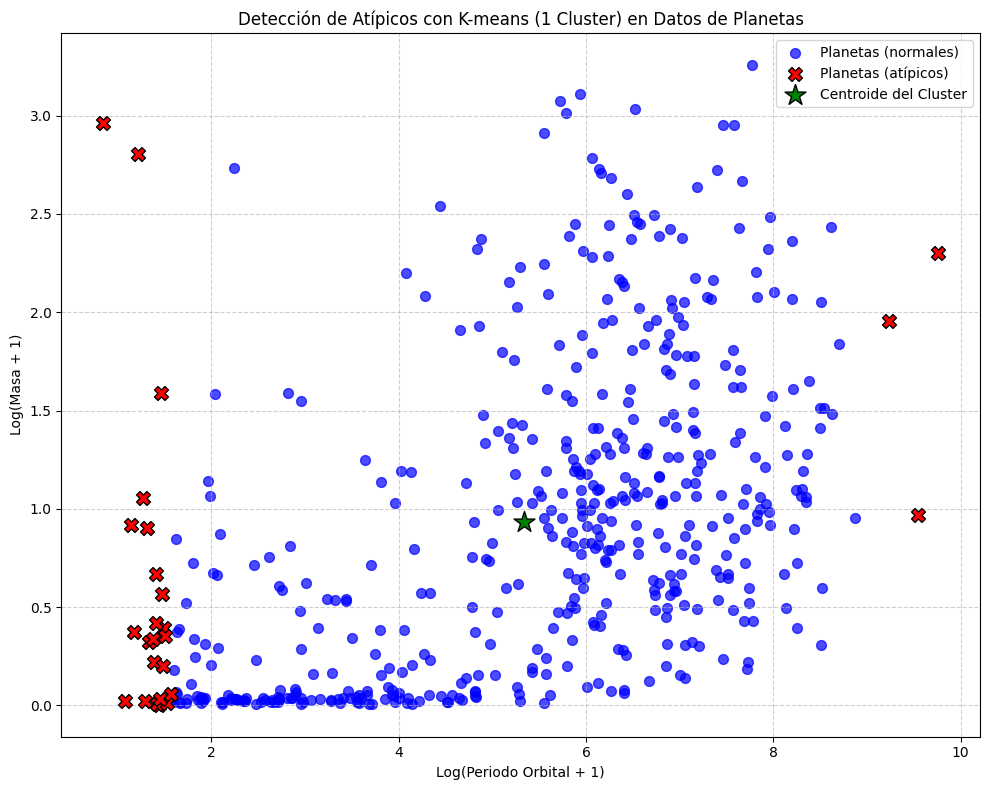

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import numpy as np

planets = sns.load_dataset("planets").dropna(subset=["orbital_period", "mass"])
X = planets[["orbital_period", "mass"]].values
X = np.log1p(X)

# K-means con un solo cluster para encontrar el centroide principal
kmeans = KMeans(n_clusters=1, random_state=42, n_init=10).fit(X)
centroid = kmeans.cluster_centers_[0]

# Calcular las distancias de cada punto al centroide
distances = np.linalg.norm(X - centroid, axis=1)

# Definir un umbral para identificar atípicos
outlier_threshold = np.percentile(distances, 95) # Puntos más allá del 95% de distancia
is_outlier = distances > outlier_threshold

plt.figure(figsize=(10,8))


plt.scatter(X[~is_outlier, 0], X[~is_outlier, 1], c='blue', s=50, alpha=0.7, label="Planetas (normales)")


plt.scatter(X[is_outlier, 0], X[is_outlier, 1], c='red', s=100, marker='X', edgecolor='black', zorder=5, label="Planetas (atípicos)")

plt.scatter(centroid[0], centroid[1], c='green', s=250, marker='*', edgecolor='black', zorder=6, label="Centroide del Cluster")

# Etiquetas y título
plt.xlabel("Log(Periodo Orbital + 1)")
plt.ylabel("Log(Masa + 1)")
plt.title("Detección de Atípicos con K-means (1 Cluster) en Datos de Planetas")


plt.legend()

plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

El gráfico muestra la distribución de planetas según su periodo orbital y masa. La presencia de los valores atípicos rojos indica planetas con combinaciones inusuales de periodo orbital y masa en comparación con la mayoría de los datos, muy alejados del centoide del cluster. Pueden representar casos extremos, como planetas muy masivos con periodos orbitales cortos o muy largos, o viceversa, que se desvían significativamente del patrón general de la población de planetas en el dataset.